In [117]:
import pandas as pd
import numpy as np

In [118]:
data = pd.read_csv('/content/healthcare_dataset.csv')

In [119]:
data.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


In [120]:
data.shape

(6000, 7)

In [121]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               6000 non-null   int64  
 1   age                      6000 non-null   int64  
 2   bmi                      6000 non-null   float64
 3   exercise_hours_per_week  6000 non-null   float64
 4   smoker                   6000 non-null   int64  
 5   blood_pressure           6000 non-null   float64
 6   diabetes                 6000 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 328.3 KB


In [122]:
data.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


In [123]:
import matplotlib.pyplot as plt
import seaborn as sb

# Age vs Diabetes

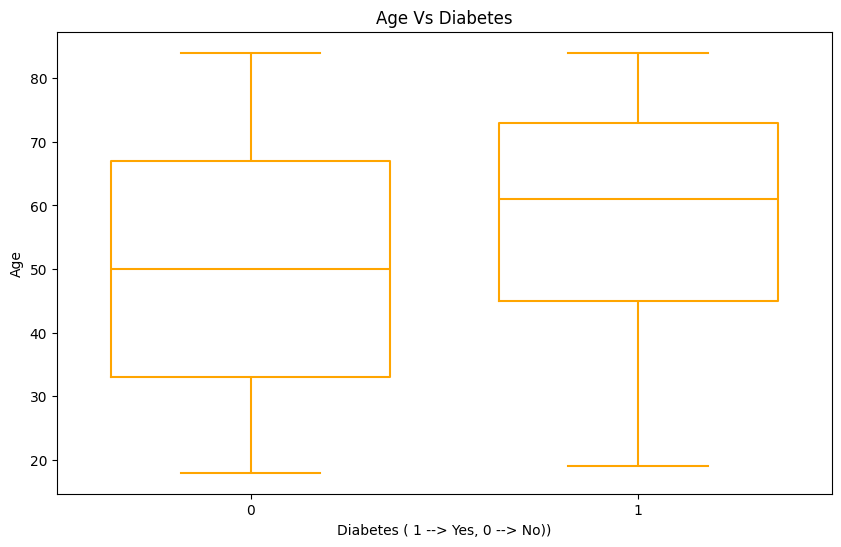

In [124]:
plt.figure(figsize=(10,6))
sb.boxplot(data=data, x='diabetes', y='age', fill=False, gap=.1, color='orange')
plt.title('Age Vs Diabetes')
plt.xlabel('Diabetes ( 1 --> Yes, 0 --> No))')
plt.ylabel('Age')
plt.show()

#### Insights
* Diabetic people have higher median age
* Age seems like a significant risk factor

# BMI Distribution | Diabetic vs Non-Diabetic

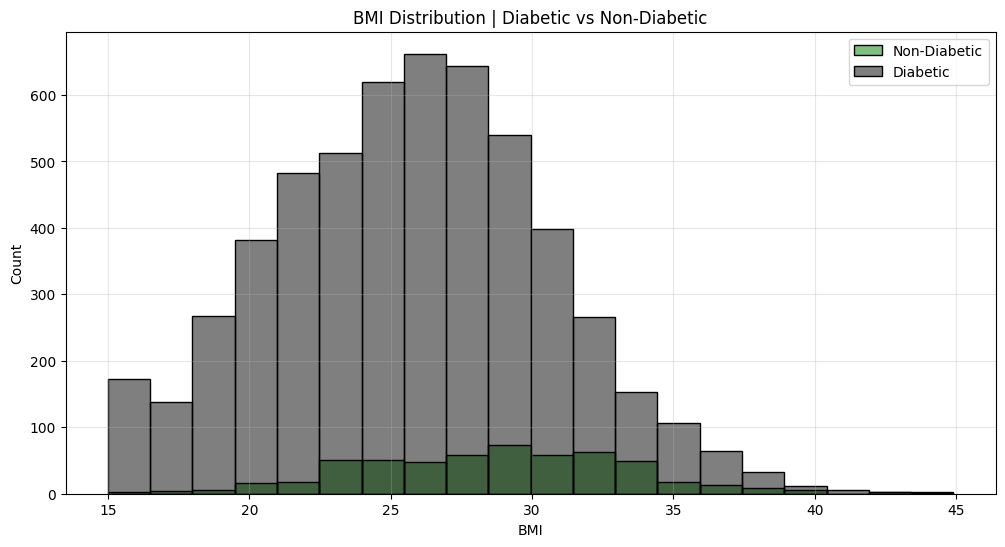

In [125]:
plt.figure(figsize=(12, 6))
sb.histplot(data=data, x='bmi', hue='diabetes', bins=20, alpha=0.5,
            palette={0: 'black', 1: 'green'})
#hue --> seperate with diabetes status (0,1)| alpha-->transparency
plt.title('BMI Distribution | Diabetic vs Non-Diabetic')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.legend(labels=['Non-Diabetic', 'Diabetic'])
plt.grid(True, alpha=0.3)
plt.show()

## Insights
* High BMI for Diabetic Patients
* BMI appears as a significant risk factor for diabetic prediction

# Exercise vs Diabetes

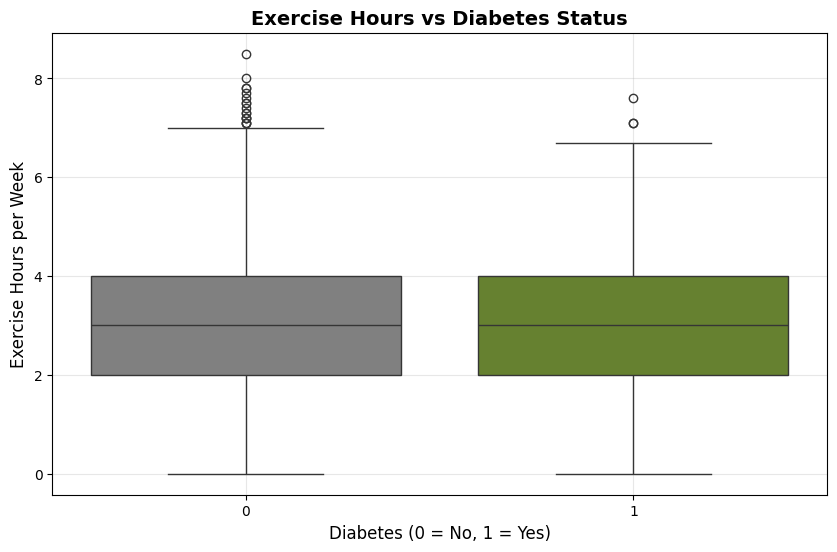

In [126]:
# Exercise vs Diabetes - Box Plot
plt.figure(figsize=(10, 6))
sb.boxplot(data=data, x='diabetes', y='exercise_hours_per_week',
           hue='diabetes', palette=['grey', 'olivedrab'], legend=False)
plt.title('Exercise Hours vs Diabetes Status', fontsize=14, fontweight='bold')
plt.xlabel('Diabetes (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Exercise Hours per Week', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## Insights
* Diabetic patients have lower median exercise hours than non-diabetic persons
* The outliers show that there are some non-diabetic persons who exercise more than 7 hours per week
* Higher physical activity helps to protect against diabetes risk

# Correlation heatmap

In [127]:
data = data.drop('patient_id', axis=1)
corr_matrix = data.corr()

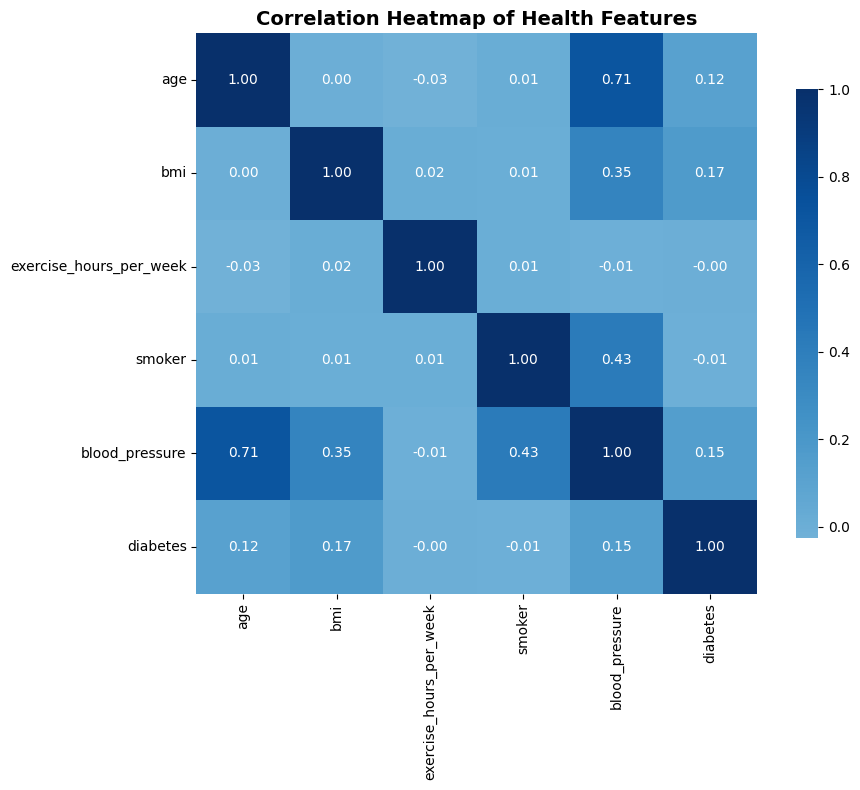

In [128]:

# calculating correlation matrix

plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap='Blues', center=0, square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Health Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Insights
* Blood Pressure increases with Age
* People with high Blood pressue have high BMI
* People doing more exercise per week have low diabetes risk
* Feature smoking shows weak correlation

## Part 2 — Machine Learning Classification Model

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [130]:
x = data.drop('diabetes', axis=1)
y = data['diabetes']

In [131]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.85)

In [132]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [133]:
# Train logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

# Make predictions
y_pred = model.predict(x_test_scaled)

In [134]:
print("Accuracy : ",accuracy_score(y_test,y_pred ))

Accuracy :  0.9044444444444445


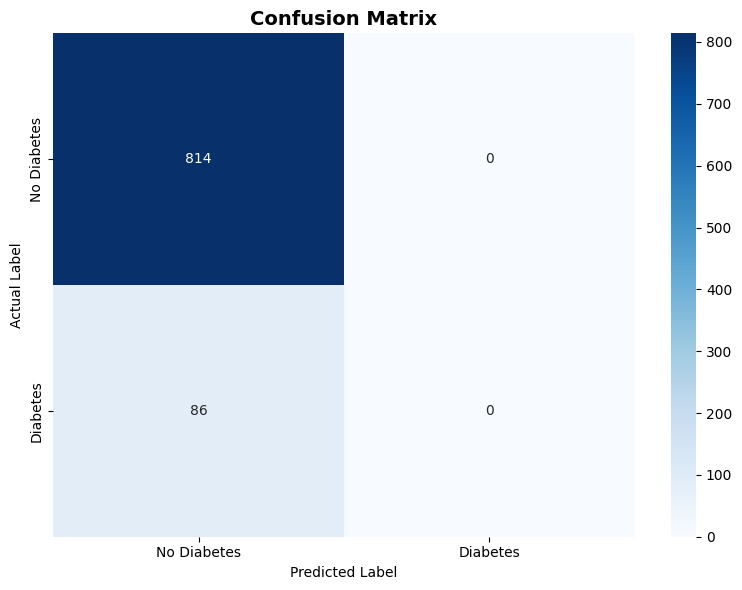

In [135]:
# Create confusion matrix with proper formatting
plt.figure(figsize=(8, 6))
c_matrix = confusion_matrix(y_test, y_pred)
sb.heatmap(c_matrix, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Diabetes', 'Diabetes'],
           yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

##### This Confusion matrix shows 0 false positives and o false negatives which is impossible in real world scenarios, which shows data is unbalanced.

## Using Class weight balancing for balancing data



In [136]:
# Train logistic regression model with class weights to balance data
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(x_train_scaled, y_train)

# Make predictions
y_pred = model.predict(x_test_scaled)

In [137]:
print("Accuracy : ",accuracy_score(y_test,y_pred ))

Accuracy :  0.65


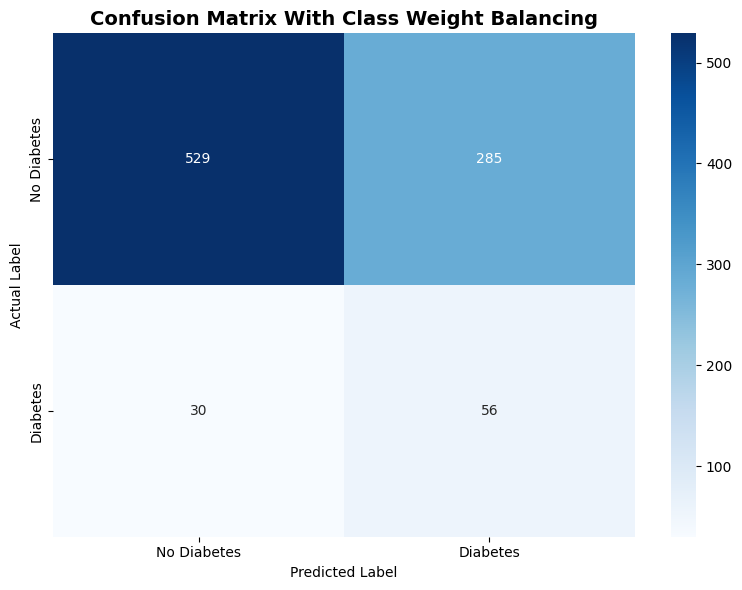

In [138]:
# Create confusion matrix with proper formatting
plt.figure(figsize=(8, 6))
c_matrix = confusion_matrix(y_test, y_pred)
sb.heatmap(c_matrix, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Diabetes', 'Diabetes'],
           yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix With Class Weight Balancing', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [139]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.65      0.77       814
           1       0.16      0.65      0.26        86

    accuracy                           0.65       900
   macro avg       0.56      0.65      0.52       900
weighted avg       0.87      0.65      0.72       900



Now with class weight balanced the accuracy become ~67% where the model can do resonable predictions

### Part 3 — Neural Network Model

In [140]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

#### Since when we use the given unbalanced data for training it will be Good at predicting the majority group (Non-diabetic) and might not works well with minority groups (Diabetic) which is concerning.
#### For preventing this Bias, SMOTE is used SMOTE (Synthetic Minority Over-sampling Technique) creates new, artificial examples of the minority group. This gives the model more data to learn from for the underrepresented class, making it better at recognizing them.

In [141]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)


In [142]:
model = keras.Sequential(
    [
        layers.Input(shape=(x_train_resampled.shape[1],),name='input'),
        layers.Dense(64,activation='relu',name='hidden_layer_1'),
        layers.Dense(32,activation='relu',name='hidden_layer_2'),
        layers.Dense(16,activation='relu',name='hidden_layer_3'),
        layers.Dense(1,activation='sigmoid',name='output_layer')
    ]
)

In [143]:
model.compile(
    optimizer = 'adam',
    loss =keras.losses.BinaryCrossentropy(name='binary_cross_entropy'),
    metrics = [
        keras.metrics.BinaryAccuracy(name='Accuracy'),
        keras.metrics.MeanSquaredError(name='MSE')
    ]
)

In [144]:
model.fit(x_train_resampled, y_train_resampled, epochs=100, validation_data=(x_test, y_test))

Epoch 1/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - Accuracy: 0.6172 - MSE: 0.2361 - loss: 0.6739 - val_Accuracy: 0.8767 - val_MSE: 0.1151 - val_loss: 0.3841
Epoch 2/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.6108 - MSE: 0.2355 - loss: 0.6670 - val_Accuracy: 0.7744 - val_MSE: 0.1607 - val_loss: 0.4934
Epoch 3/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.6168 - MSE: 0.2316 - loss: 0.6573 - val_Accuracy: 0.6644 - val_MSE: 0.2070 - val_loss: 0.5992
Epoch 4/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.6260 - MSE: 0.2259 - loss: 0.6427 - val_Accuracy: 0.5133 - val_MSE: 0.2696 - val_loss: 0.7373
Epoch 5/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.6268 - MSE: 0.2271 - loss: 0.6463 - val_Accuracy: 0.5333 - val_MSE: 0.2509 - val_loss: 0.6909
Epoch 6/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.6330 - MSE: 0.2222 - loss: 0.6343 - val_Accuracy: 0.4867 - val_MSE: 0.2691 - val_loss: 0.7317
Epoch 7/100
291/291 ━━━━━━━━━━━━━━

In [147]:
loss, accuracy, mse = model.evaluate(x_test, y_test)
print("Accuracy:", accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.6667 - MSE: 0.1936 - loss: 0.5553
Accuracy: 0.6666666865348816


In [154]:
predict = (model.predict(x_test)>0.5).astype("int32")
#print(predict)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


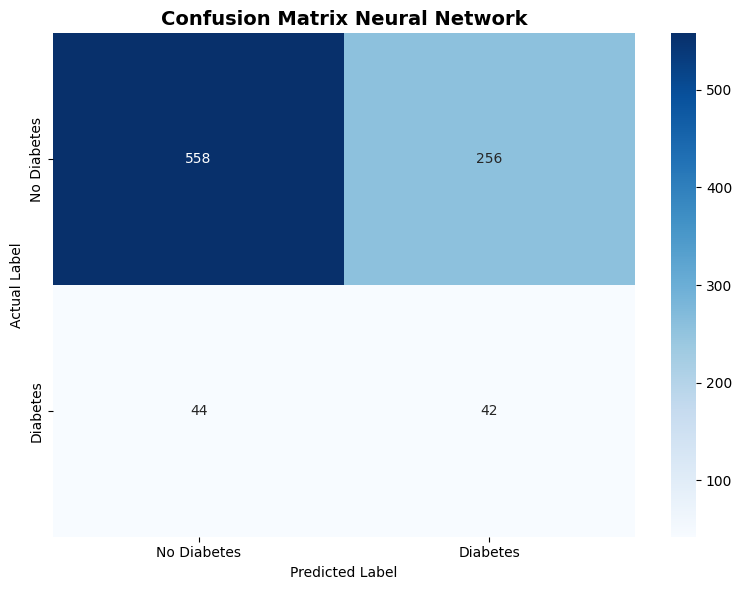

In [155]:
# Create confusion matrix with proper formatting
plt.figure(figsize=(8, 6))
confu_matrix = confusion_matrix(y_test, predict)
sb.heatmap(confu_matrix, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Diabetes', 'Diabetes'],
           yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix Neural Network', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [157]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.93      0.69      0.79       814
           1       0.14      0.49      0.22        86

    accuracy                           0.67       900
   macro avg       0.53      0.59      0.50       900
weighted avg       0.85      0.67      0.73       900



## Part 4 — Model Comparison

### Model Comparison: A Simpler Look

**1. How Accurate Are They?**

*   **Logistic Regression (using balanced data):** About 65% accurate.
*   **Neural Network (using SMOTE):** About 66.7% accurate.

The Neural Network model is slightly more accurate overall than the Logistic Regression model, especially after we made sure both models had fair training data.

**2. Strength of ML Model**

*   **Easy to Understand:** It's like a simple math equation, so we can easily see how each factor (like age or BMI) influences the outcome.
*   **Fast and Efficient:** It trains quickly, especially with smaller datasets.
*   **Good Starting Point:** It's often a great first model to try, giving us a basic idea of performance.
*   **Doesn't Need Lots of Data:** It can work pretty well even if you don't have a huge amount of information.

**3. Strength of Neural Networks**

*   **Finds Complex Patterns:** They can discover hidden, non-straightforward relationships in the data that simpler models miss.
*   **Learns Features Itself:** They can automatically figure out important data characteristics, so you don't have to do as much manual work.
*   **Great with Big Data:** The more data you give them, the better they tend to perform.
*   **Very Powerful:** They can achieve top results on tough problems when they have enough data and computing power.

**4. Limitations**

**Logistic Regression :**
*   **Only Straight Lines:** It assumes relationships are simple and linear, which isn't always true in real life.
*   **Sensitive to Extremes:** Unusual data points (outliers) can strongly affect its results.
*   **Needs Hand-Crafted Features:** You often need to carefully prepare the data's features for it to work best.

**Neural Network :**
*   **Hard to Explain (Black Box):** It's tough to understand exactly *why* a neural network makes a certain prediction because its internal workings are very complex.
*   **Needs Tons of Data:** They require a lot of data to train effectively without just memorizing the training examples.
*   **Takes a Lot of Power:** Training them can use a lot of computer resources and time.
*   **Tricky Setup:** Getting them to work well means carefully choosing many settings (like layers, neurons, and learning speed), which can be complicated.
*   **Can Over-Learn:** They can sometimes get too good at the training data and fail to predict well on new, unseen data.

**5. Why Neural network is better here**

Even with just a small improvement, the neural network likely performed better because it's good at finding more complex links between health factors and diabetes. Conditions like diabetes aren't usually tied to single factors in a simple, straight-line way. The neural network's design allows it to catch these nuanced connections better, especially after we used SMOTE to balance the dataset.

**6. When Is Logistic Regression the Better?**

*   **When Explaining is Key:** If you absolutely need to understand how each specific factor contributes to the outcome (like in medical studies).
*   **For Smaller Datasets:** If you don't have a massive amount of data, Logistic Regression can give good results without the complexity of a neural network.
*   **When You Need it Fast and Simple:** For quick insights or as a first step before trying more advanced methods.
*   **If Relationships Are Simple:** If you have good reasons to believe that the connections in your data are mostly straightforward.
*   **Limited Resources:** If you don't have powerful computers or a lot of time for training.